# 06 - Feature Analysis e Feature Selection

## Obiettivo del notebook

Questo notebook analizza la significatività delle feature disponibili e delle feature ingegnerizzate, con l'obiettivo di supportare decisioni operative su quali variabili mantenere, trasformare o scartare nelle fasi successive di modellazione.

La feature selection viene trattata come fase preliminare alla model comparison: le decisioni prese qui dovranno essere validate quantitativamente tramite micro-F1 score.

# IMPORT & DATA LOADING

In [1]:
import pandas as pd
import numpy as np

import src.preprocessing as prep
from src.feature_selection import FeatureSelection

X, y = prep.preprocess()
fs = FeatureSelection()

# Data Preparation

In [2]:
print(X.head())
print(X.info())
print(y.value_counts())

   geo_level_1_id  geo_level_2_id  geo_level_3_id  count_floors_pre_eq  age  \
0               6             487           12198                    2   30   
1               8             900            2812                    2   10   
2              21             363            8973                    2   10   
3              22             418           10694                    2   10   
4              11             131            1488                    3   30   

   area_percentage  height_percentage land_surface_condition foundation_type  \
0                6                  5                      t               r   
1                8                  7                      o               r   
2                5                  5                      t               r   
3                6                  5                      t               r   
4                8                  9                      t               r   

  roof_type  ... has_secondary_use_gov_offic

## Feature audit preliminare

Prima di applicare metodi automatici di feature selection, costruiamo una tabella di audit delle feature. L'obiettivo è classificare ogni variabile per gruppo logico, tipo, cardinalità e azione preliminare.

Questa fase non decide ancora definitivamente quali feature eliminare: serve a identificare feature da tenere, trasformare, validare o trattare con attenzione durante la modellazione.


In [ ]:
# Feature audit preliminare

def classify_feature_group(col: str) -> str:
    if col.startswith("geo_level_"):
        return "geografica"

    if col in ["age", "age_clipped", "age_group"]:
        return "eta"

    if col in ["area_percentage", "height_percentage", "building_volume_proxy"]:
        return "dimensionale"

    if col.startswith("has_superstructure_") or col in [
        "total_superstructure_count",
        "has_fragile_material",
        "has_engineered_structure",
    ]:
        return "strutturale"

    if col.startswith("has_secondary_use") or col == "total_secondary_use_count":
        return "uso_secondario"

    if col in ["count_floors_pre_eq", "count_families"]:
        return "numerica_strutturale"

    if col in [
        "land_surface_condition",
        "foundation_type",
        "roof_type",
        "ground_floor_type",
        "other_floor_type",
        "position",
        "plan_configuration",
        "legal_ownership_status",
    ]:
        return "categorica_strutturale"

    return "altro"


def assign_preliminary_action(row: pd.Series) -> str:
    feature = row["feature"]
    group = row["group"]

    if feature == "building_id":
        return "drop_id"

    if group == "geografica":
        if feature == "geo_level_1_id":
            return "keep_as_categorical"
        return "keep_but_test_encoding"

    if feature == "age":
        return "transform_and_validate"

    if feature in ["age_clipped", "age_group"]:
        return "keep_and_validate"

    if group in ["strutturale", "categorica_strutturale"]:
        return "keep_high_priority"

    if group == "uso_secondario":
        return "keep_initially_validate"

    if group in ["dimensionale", "numerica_strutturale"]:
        return "keep_and_validate"

    return "keep_initially"


feature_audit = pd.DataFrame({
    "feature": X.columns,
    "dtype": [str(X[col].dtype) for col in X.columns],
    "n_unique": [X[col].nunique(dropna=False) for col in X.columns],
    "missing_count": [X[col].isna().sum() for col in X.columns],
    "missing_pct": [X[col].isna().mean() * 100 for col in X.columns],
})

feature_audit["unique_ratio"] = feature_audit["n_unique"] / len(X)
feature_audit["group"] = feature_audit["feature"].apply(classify_feature_group)
feature_audit["preliminary_action"] = feature_audit.apply(assign_preliminary_action, axis=1)

feature_audit = feature_audit[
    [
        "feature",
        "group",
        "dtype",
        "n_unique",
        "unique_ratio",
        "missing_count",
        "missing_pct",
        "preliminary_action",
    ]
].sort_values(["group", "n_unique"], ascending=[True, False])

feature_audit


In [ ]:
# Sintesi per gruppo di feature

feature_group_audit = (
    feature_audit
    .groupby("group")
    .agg(
        n_features=("feature", "count"),
        max_cardinality=("n_unique", "max"),
        mean_cardinality=("n_unique", "mean"),
        actions=("preliminary_action", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values("n_features", ascending=False)
)

feature_group_audit


### Prime decisioni operative

- `building_id` non deve essere usato come feature predittiva.
- Le feature geografiche devono essere trattate come categoriche identificative, non come variabili numeriche continue.
- `geo_level_2_id` e `geo_level_3_id` richiedono attenzione perché possono generare molte colonne dopo encoding.
- Le feature strutturali e le feature categoriche strutturali sono candidate ad alta priorità.
- Le feature di uso secondario vengono mantenute inizialmente, ma il loro contributo va validato.
- `age` va trattata tramite trasformazioni come `age_clipped` e `age_group`, evitando di usare direttamente il valore estremo `age = 995` come età ordinaria.
- Le decisioni preliminari devono essere validate con micro-F1 nelle fasi successive.


# Metodi di Feature Selection

In maniera preliminare, si è deciso di implementare le strategie di feature Selection, in modo tale da fare una prima analisi concreta delle feature. I metodi di Feature Selection implementati sono stati i seguenti:

- ### Correlation Matrix
- ### Chi-2
- ### Mutual Information - Entropia/Information Gain
- ### Random Forest
- ### XGboost
- ### Catboost

## Correlation Matrix

Descrizione metodo:

In [ ]:
import src.utils as utls
    
def correlation_matrix(self, X: pd.DataFrame, y: pd.Series) -> pd.Series:

        X_encoded = pd.get_dummies(X)
        # Combine features + target
        df = pd.concat([X_encoded, y], axis=1)
        # Keep only numeric columns
        corr_matrix = df.corr()
        # Correlation with target
        utls.plot_correlation_heatmap(corr_matrix, title="Correlation Heatmap between features")

        corr_target = (
            corr_matrix[y.name]
            .sort_values(ascending=False)
        )
        # Remove target itself
        ranking = corr_target.drop(y.name)
        utls.plot_feature_ranking(ranking, title="Correlation Matrix")
        return ranking

### Risultati

In [5]:
X, y = prep.preprocess()
ranking = fs.correlation_matrix(X, y)
print(ranking)


has_fragile_material                      0.399507
foundation_type_r                         0.343355
has_superstructure_mud_mortar_stone       0.291325
ground_floor_type_f                       0.234755
other_floor_type_q                        0.166759
                                            ...   
has_superstructure_cement_mortar_brick   -0.254131
foundation_type_i                        -0.263901
roof_type_x                              -0.280106
ground_floor_type_v                      -0.318720
has_engineered_structure                 -0.319421
Name: damage_grade, Length: 79, dtype: float64


![correlation_heatmap](../plots/correlation_heatmap.png)

##  Chi-2

In [ ]:
@staticmethod
def chi_square_selection(X: pd.DataFrame, y: pd.Series, p_value_threshold: float = 0.05):
        # tengo solo colonne numeriche
        #X_numeric = X.select_dtypes(include=np.number)
        X_encoded = pd.get_dummies(X)
        # applico test Chi-quadrato
        chi_scores, p_values = chi2(X_encoded, y)

        results = pd.DataFrame({
            "Feature": X_encoded.columns,
            "Chi2 Score": chi_scores,
            "p-value": p_values,
        })

        print(results.sort_values("Chi2 Score", ascending=False))
        results = results[results["p-value"] < p_value_threshold]
        print(results.sort_values("Chi2 Score", ascending=False))

        selected_features = results["Feature"]

        final_df = X_encoded[selected_features].copy()
        final_df[y.name] = y

        return final_df

### Risultati

In [6]:
final_df_chi2 = fs.chi_square_selection(X, y)

                         Feature     Chi2 Score   p-value
35                   age_clipped  145546.983135  0.000000
1                 geo_level_2_id  128238.967545  0.000000
4                            age   89437.601577  0.000000
2                 geo_level_3_id   83664.759142  0.000000
34         building_volume_proxy   66425.490074  0.000000
..                           ...            ...       ...
64          plan_configuration_m      13.643520  0.001090
75            age_group_100_plus       9.043394  0.010871
63          plan_configuration_f       3.343054  0.187960
65          plan_configuration_n       1.651878  0.437824
28  has_secondary_use_use_police       1.586290  0.452420

[79 rows x 3 columns]
                          Feature     Chi2 Score       p-value
35                    age_clipped  145546.983135  0.000000e+00
1                  geo_level_2_id  128238.967545  0.000000e+00
4                             age   89437.601577  0.000000e+00
2                  geo_level_

![correlation_heatmap](../plots/correlation_heatmap.png)

## Mutual Information

In [ ]:
from src.utils import plot_feature_ranking
from sklearn.feature_selection import mutual_info_classif
@staticmethod
def information_gain_selection( X: pd.DataFrame, y: pd.Series, threshold: float = 0.02):
        # include TUTTE le feature (numeriche + categoriche)
        X_encoded = pd.get_dummies(X)
        mi = mutual_info_classif(X_encoded, y, random_state=42)

        scores = pd.Series(mi, index=X_encoded.columns)
        plot_feature_ranking(scores, title="Mutual Information")

        print(scores.sort_values(ascending=False))
        selected = scores[scores > threshold].index

        final_df = X_encoded[selected].copy()
        final_df[y.name] = y.values

        return final_df

### Risultati

In [ ]:
final_df_MU = fs.information_gain_selection(X, y)
print(final_df_MU.head())

## Relief Selection

In [ ]:
    def Relief_selection(self, X: pd.DataFrame, y: pd.Series):
        X_encoded = pd.get_dummies(X)
        relief = ReliefF(n_neighbors=100)
        relief.fit(X_encoded.values, y)

        scores = pd.Series(relief.feature_importances_, index=X.columns)
        ranking = scores.sort_values(ascending=False)

        print(ranking)
        plot_feature_ranking( ranking, title="ReliefF Ranking")
        top_features = ranking.head(5).index
        X_selected = X[top_features]
        print(X_selected.head())
        return X_selected


### Risultati

Non è possibile utilizzare questo approccio nel nostro problema, il dataset risulta troppo grande -> complessità a O(n^2)

## Random Forest

In [ ]:
@staticmethod
def random_forest_selection(X: pd.DataFrame, y: pd.Series, threshold: float = 0.01):
        # encoding categoriche
        X_encoded = pd.get_dummies(X, drop_first=False)

        # modello Random Forest
        rf = RandomForestClassifier( n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_encoded, y)

        # importance scores
        scores = pd.Series( rf.feature_importances_, index=X_encoded.columns)

        ranking = scores.sort_values(ascending=False)

        print(ranking)
        plot_feature_ranking(ranking, title="Random Forest Importance")
        # selezione feature importanti
        selected_features = ranking[ranking > threshold].index
        # dataset finale
        final_df = X_encoded[selected_features].copy()
        final_df[y.name] = y.values
        return final_df

### Risultati

geo_level_3_id                   0.140364
geo_level_1_id                   0.128296
geo_level_2_id                   0.126558
building_volume_proxy            0.084211
area_percentage                  0.072043
                                   ...   
has_secondary_use_health_post    0.000039
plan_configuration_m             0.000036
has_secondary_use_gov_office     0.000026
has_secondary_use_use_police     0.000025
plan_configuration_f             0.000019
Length: 79, dtype: float64


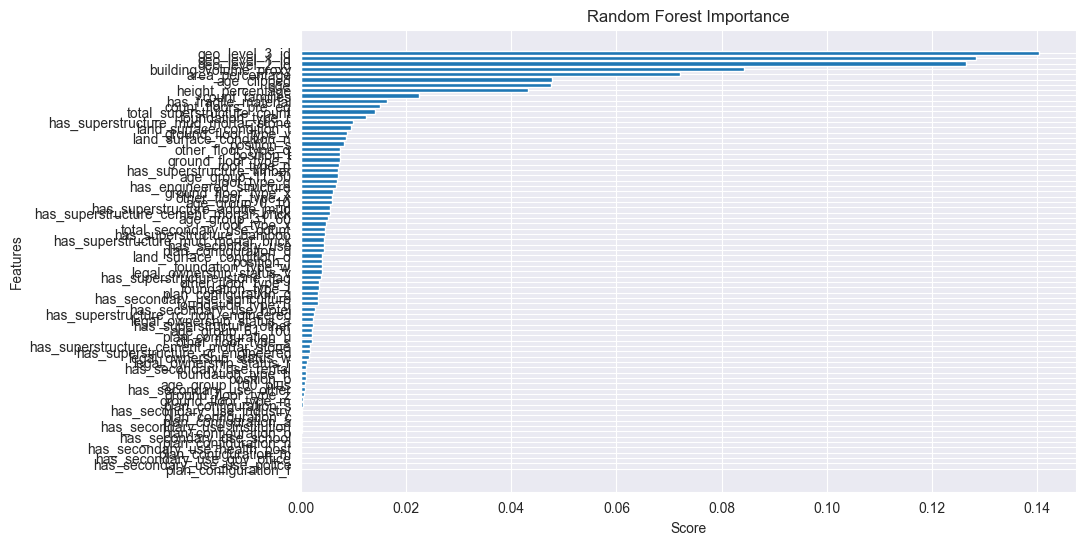

In [ ]:
final_df_random_forest = fs.random_forest_selection(X, y)
print(final_df_random_forest.head())

## XGBoost

In [ ]:
    def xgboost_selection(X: pd.DataFrame, y: pd.Series, threshold: float = 0.01):
        # encoding categoriche
        X_encoded = pd.get_dummies(X)

        # modello XGBoost
        model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)
        model.fit(X_encoded, y_encoded)

        # importance
        scores = pd.Series( model.feature_importances_, index=X_encoded.columns)

        ranking = scores.sort_values( ascending=False)
        plot_feature_ranking( ranking, title="XGBoost Importance")
        print(ranking)

        # selezione feature
        selected_features = ranking[ranking > threshold].index

        final_df = X_encoded[selected_features].copy()
        final_df[y.name] = y.values
        return final_df

### Risultati

In [ ]:
df_xgb = fs.xgboost_selection(X, y)

## CatBoost

In [ ]:
@staticmethod
    def catboost_selection( X: pd.DataFrame, y: pd.Series, threshold: float = 0.01):
        # individua colonne categoriche
        categorical_cols = X.select_dtypes( include=["object", "category"]).columns.tolist()

        # indici colonne categoriche
        cat_indices = [
            X.columns.get_loc(col)
            for col in categorical_cols
        ]

        # modello CatBoost
        model = CatBoostClassifier( iterations=100, random_state=42, verbose=0,)
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)
        model.fit( X, y_encoded, cat_features=cat_indices)

        # importance
        scores = pd.Series( model.feature_importances_, index=X.columns)

        ranking = scores.sort_values(ascending=False)
        plot_feature_ranking( ranking, title="CatBoost Importance")
        print(ranking)

        # selezione feature
        selected_features = ranking[ ranking > threshold].index
        final_df = X[ selected_features].copy()
        final_df[y.name] = y.values
        return final_df

### Risultati

df_cat = fs.catboost_selection(X, y)

## Metodi di Feature Extraction